# Crop Data Preprocessing & EDA
This notebook follows a structured workflow to clean, validate, explore, and split the crop recommendation dataset.

## 1. Import libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Configure visualizations
sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load raw CSV

In [18]:
df = pd.read_csv('/content/Crop_recommendation.csv')
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Understand the dataset

In [19]:
print('--- Shape of Dataset ---')
print(df.shape)

print('\n--- Columns ---')
print(df.columns.tolist())

print('\n--- Data Types ---')
print(df.dtypes)

print('\n--- Basic Statistics ---')
display(df.describe())

--- Shape of Dataset ---
(2200, 8)

--- Columns ---
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

--- Data Types ---
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

--- Basic Statistics ---


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 4. Data validation

In [20]:
print('--- Missing Values ---')
print(df.isnull().sum())

print('\n--- Duplicate Rows ---')
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

print('\n--- Unique Target Classes ---')
print(df['label'].unique())
print(f'Total classes: {df["label"].nunique()}')

--- Missing Values ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 0

--- Unique Target Classes ---
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']
Total classes: 22


## 5. EDA (Exploratory Data Analysis)

/tmp/ipykernel_1425/1846126602.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')


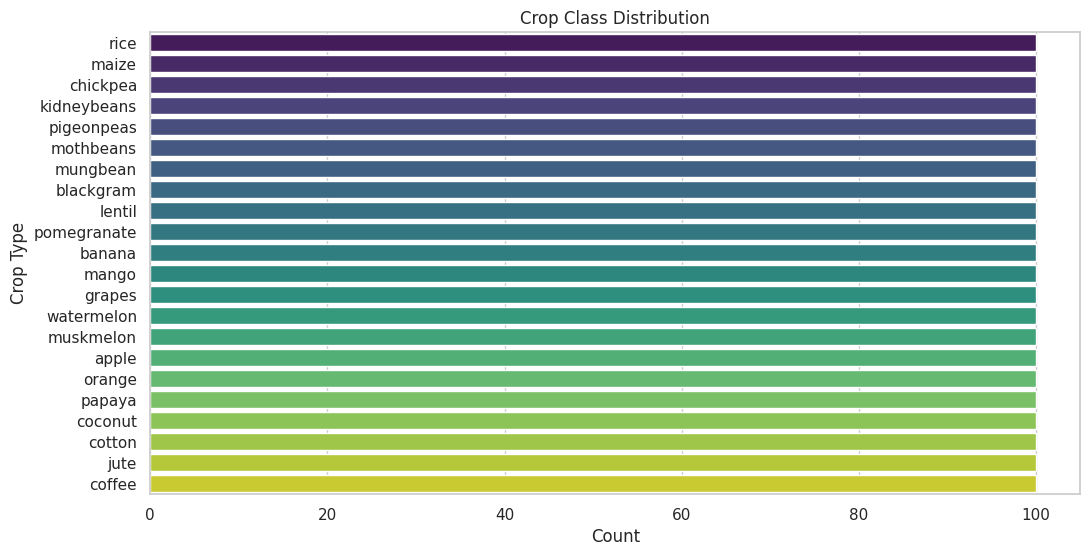

In [21]:
# Class distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Crop Class Distribution')
plt.xlabel('Count')
plt.ylabel('Crop Type')
plt.show()

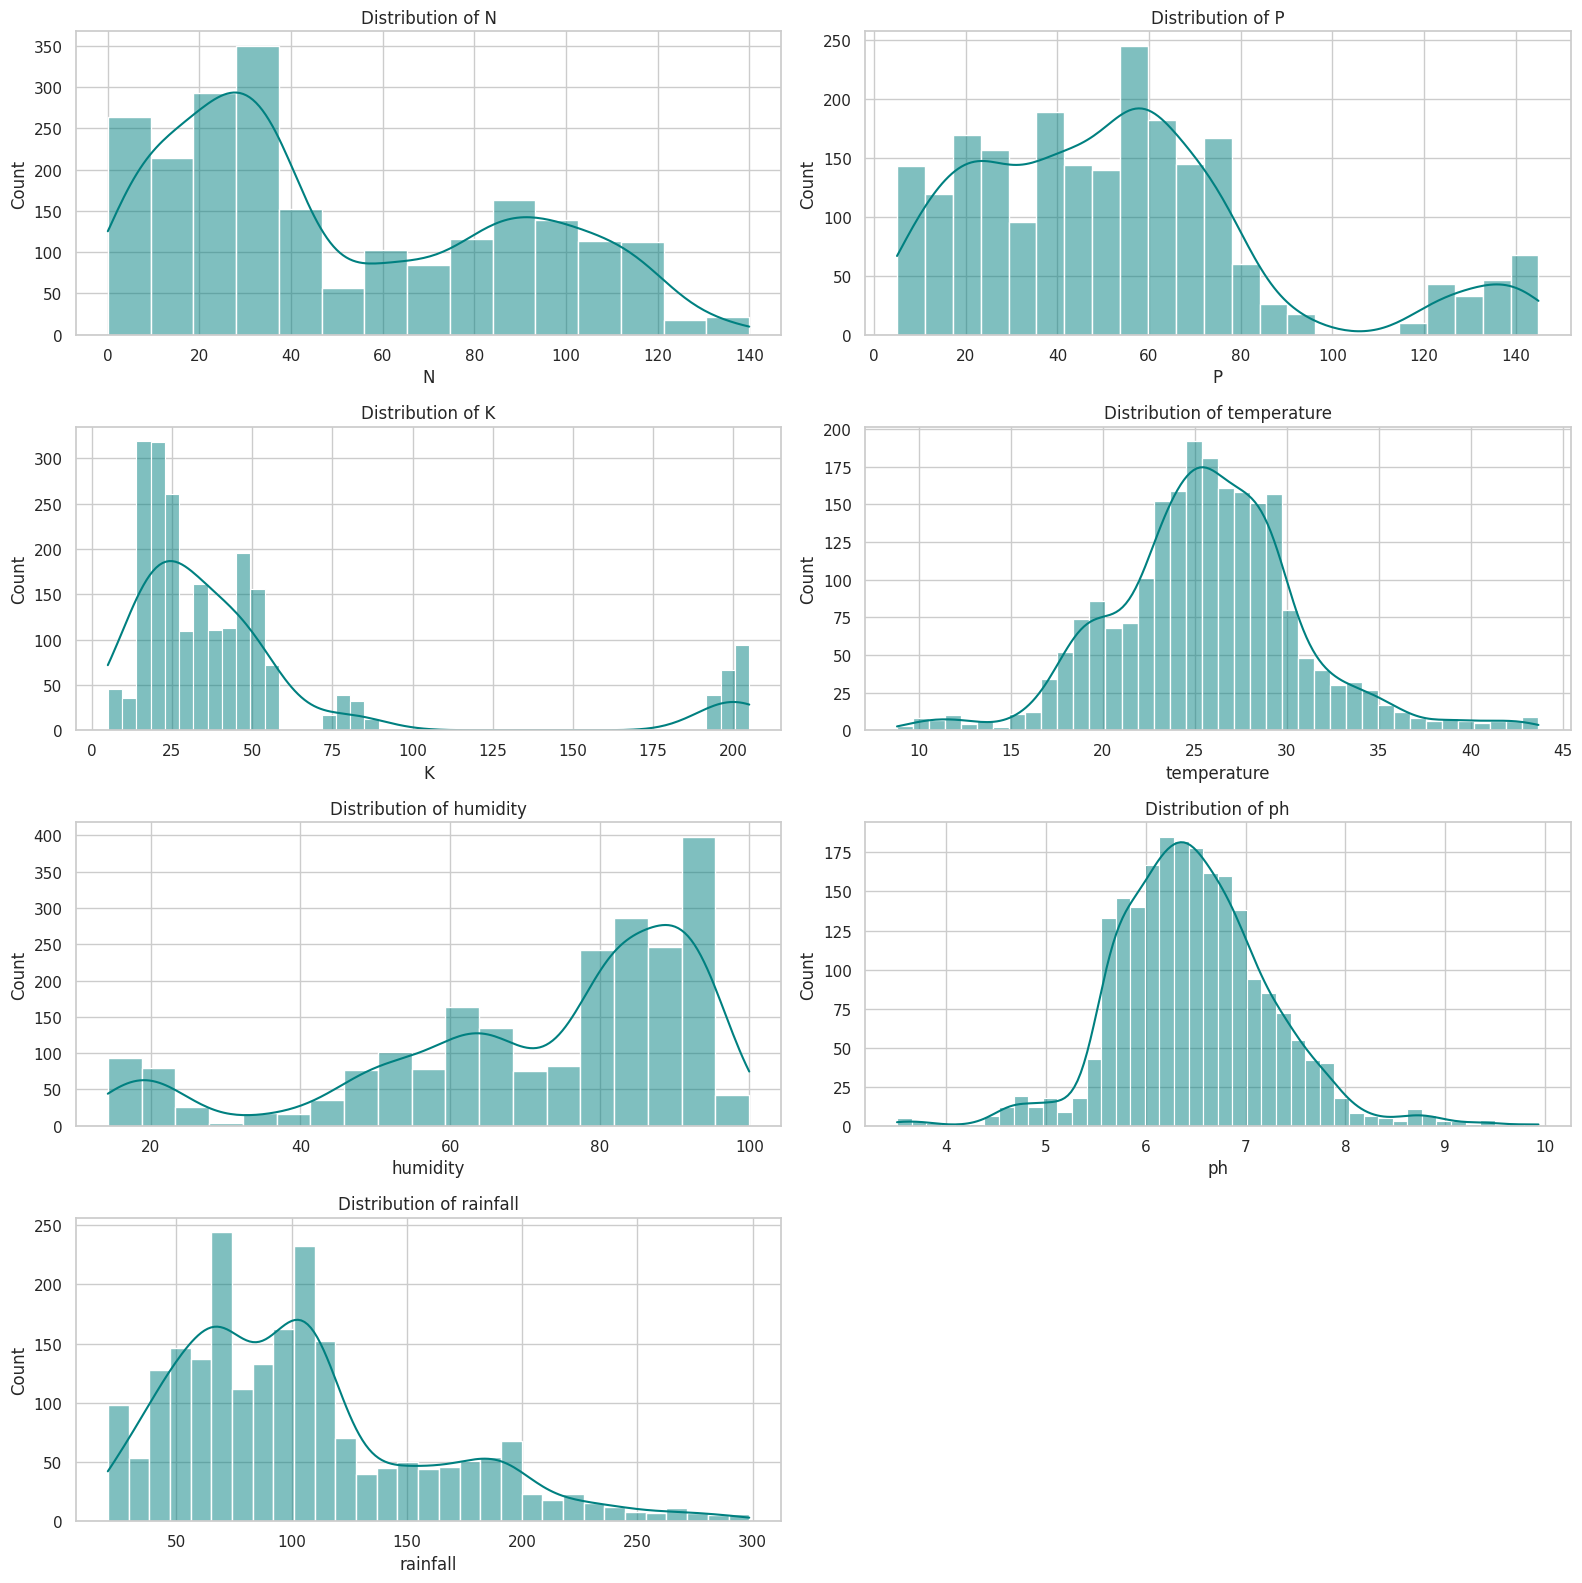

In [22]:
# Feature distributions
numerical_cols = df.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

# Hide extra subplot if any
if len(numerical_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [23]:
# Crop-wise feature average analysis
crop_means = df.groupby('label').mean(numeric_only=True)
display(crop_means)

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


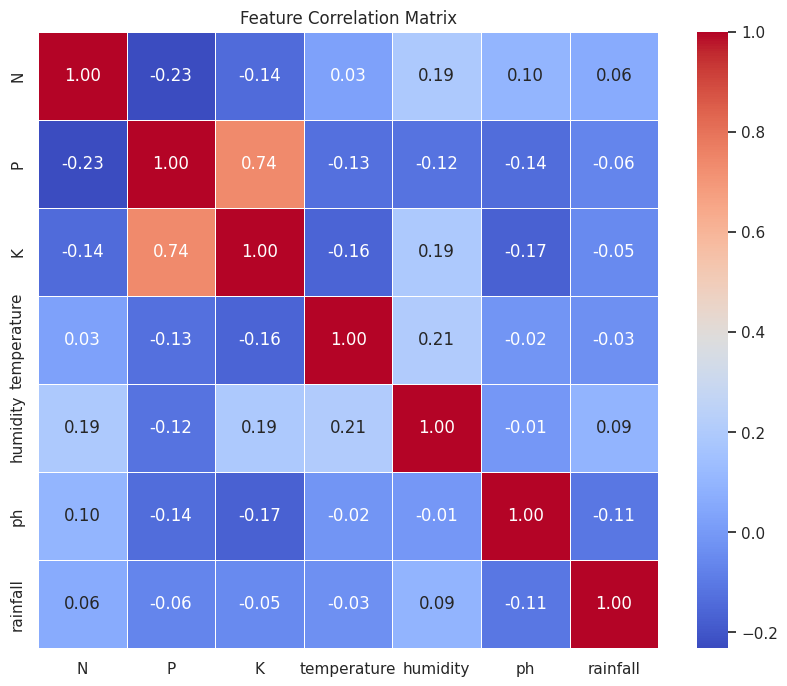

In [24]:
# Correlation analysis
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

## 6. Data quality analysis

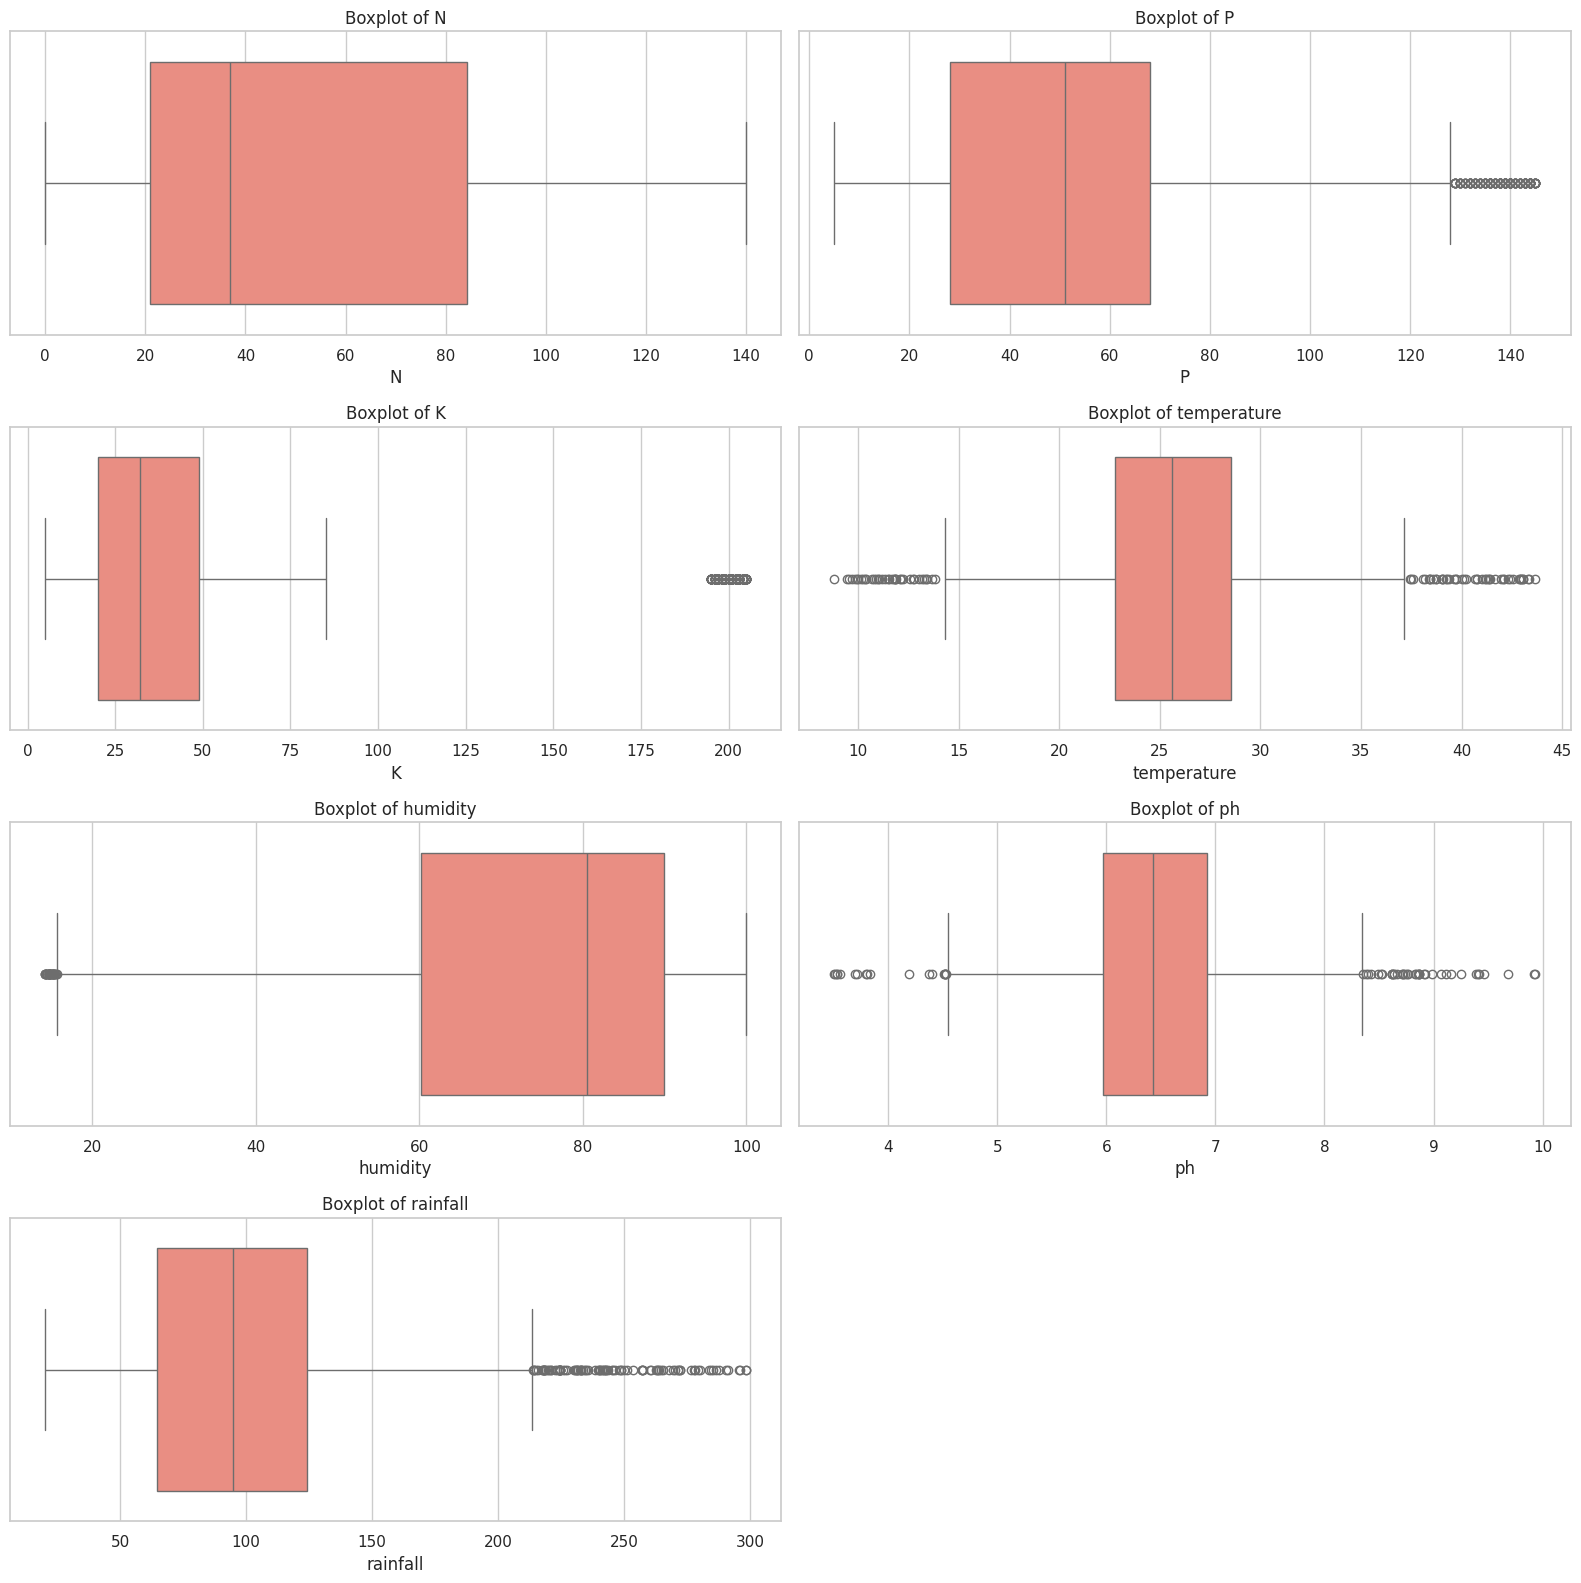

In [25]:
# Boxplots to identify outliers and suspicious values
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot of {col}')

if len(numerical_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## 7. Define X and y

In [26]:
X = df.drop(columns=['label'])
y = df['label']

print(f'Feature space shape (X): {X.shape}')
print(f'Target label shape (y): {y.shape}')

Feature space shape (X): (2200, 7)
Target label shape (y): (2200,)


## 8. Train/Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (1760, 7)
Test shape: (440, 7)


## 9. Preprocessing design

In [28]:
# Standardize numerical features using StandardScaler
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

display(X_train_scaled.head())

,N,P,K,temperature,humidity,ph,rainfall
0,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440
1,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677
2,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001
3,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744
4,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941


## 10. Save/prepare dataset information

In [29]:
import joblib

# Save scaled data and scaler for downstream model development
joblib.dump(scaler, 'crop_scaler.pkl')

# Saving datasets with requested naming convention
X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print('Preprocessing configurations and data objects saved successfully!')

Preprocessing configurations and data objects saved successfully!
